In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Import Required Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Install UCI Dataset Repository Package

In [10]:
%pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Load Phishing Websites Dataset

In [15]:
import pandas as pd
from scipy.io import arff
from urllib.request import urlopen
from zipfile import ZipFile
from io import BytesIO, TextIOWrapper

url = "https://archive.ics.uci.edu/static/public/327/phishing+websites.zip"

response = urlopen(url)

with ZipFile(BytesIO(response.read())) as zip_file:
    with zip_file.open("Training Dataset.arff") as file:
        text_file = TextIOWrapper(file, encoding="utf-8")
        dataset, meta = arff.loadarff(text_file)

data = pd.DataFrame(dataset)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [16]:
data.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'


In [17]:
print("Dataset Shape:", data.shape)
print("Number of Instances:", data.shape[0])
print("Number of Columns:", data.shape[1])

Dataset Shape: (11055, 31)
Number of Instances: 11055
Number of Columns: 31


In [18]:
print("Dataset Columns:")
print(data.columns.tolist())

Dataset Columns:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

In [20]:
print("Unique values in Result:")
print(data['Result'].unique())

print("\nClass distribution:")
print(data['Result'].value_counts())

Unique values in Result:
[b'-1' b'1']

Class distribution:
Result
b'1'     6157
b'-1'    4898
Name: count, dtype: int64


In [21]:
data = data.apply(
    lambda column: column.map(
        lambda value: int(value.decode()) if isinstance(value, bytes) else int(value)
    )
)

print("Dataset values converted to numeric format successfully.")

Dataset values converted to numeric format successfully.


In [22]:
print("Data Types:")
print(data.dtypes)

print("\nFirst Five Rows:")
display(data.head())

Data Types:
having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                 

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [23]:
print("Total Missing Values:", data.isnull().sum().sum())

Total Missing Values: 0


In [24]:
X = data.drop('Result', axis=1)
y = data['Result']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (11055, 30)
Target Shape: (11055,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (8844, 30)
Testing Feature Shape: (2211, 30)
Training Target Shape: (8844,)
Testing Target Shape: (2211,)


In [27]:
test_data = X_test.copy()
test_data['Result'] = y_test

test_data.to_csv('test_data.csv', index=False)

print("Test data saved successfully.")
print("Test Data Shape:", test_data.shape)

Test data saved successfully.
Test Data Shape: (2211, 31)


In [28]:
import zipfile

with zipfile.ZipFile('test_data.zip', 'w', zipfile.ZIP_DEFLATED) as zip_file:
    zip_file.write('test_data.csv')

print("test_data.zip created successfully.")

test_data.zip created successfully.


## Feature Scaling

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled Training Shape: (8844, 30)
Scaled Testing Shape: (2211, 30)


## Train Logistic Regression Model

In [30]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Generate Logistic Regression Predictions

In [31]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression predictions generated successfully.")
print("Number of Predictions:", len(y_pred_logistic))

Logistic Regression predictions generated successfully.
Number of Predictions: 2211


## Evaluate Logistic Regression

In [32]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_mcc = matthews_corrcoef(y_test, y_pred_logistic)

print("Logistic Regression Evaluation Metrics")
print("Accuracy :", round(logistic_accuracy, 4))
print("AUC Score:", round(logistic_auc, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("MCC Score:", round(logistic_mcc, 4))

Logistic Regression Evaluation Metrics
Accuracy : 0.9285
AUC Score: 0.9808
Precision: 0.9234
Recall   : 0.9504
F1 Score : 0.9367
MCC Score: 0.8551


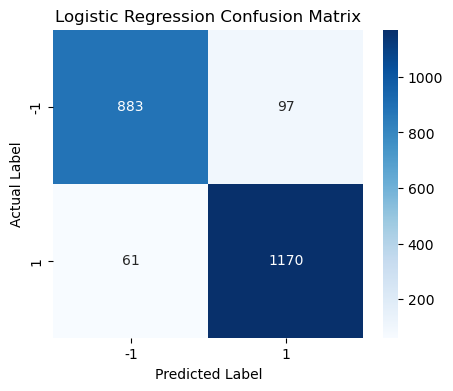

In [33]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['-1', '1'],
    yticklabels=['-1', '1']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Train Decision Tree Classifier

In [34]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


## Generate Decision Tree Predictions

In [35]:
y_pred_dt = decision_tree_model.predict(X_test)

y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")
print("Number of Predictions:", len(y_pred_dt))

Decision Tree predictions generated successfully.
Number of Predictions: 2211


## Evaluate Decision Tree Classifier

In [38]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_mcc = matthews_corrcoef(y_test, y_pred_dt)

print("Decision Tree Evaluation Metrics")
print("Accuracy :", round(dt_accuracy, 4))
print("AUC Score:", round(dt_auc, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("MCC Score:", round(dt_mcc, 4))

Decision Tree Evaluation Metrics
Accuracy : 0.9711
AUC Score: 0.9805
Precision: 0.9702
Recall   : 0.9781
F1 Score : 0.9741
MCC Score: 0.9413


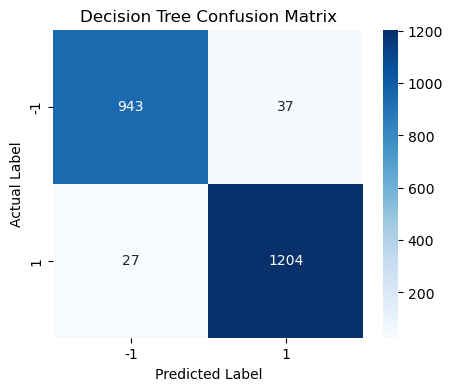

In [39]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['-1', '1'],
    yticklabels=['-1', '1']
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Train k-Nearest Neighbors Classifier

In [40]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("kNN Classifier trained successfully.")

kNN Classifier trained successfully.


## Generate kNN Predictions

In [41]:
y_pred_knn = knn_model.predict(X_test_scaled)

y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("kNN predictions generated successfully.")
print("Number of Predictions:", len(y_pred_knn))

kNN predictions generated successfully.
Number of Predictions: 2211


## Evaluate kNN Classifier

In [42]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_mcc = matthews_corrcoef(y_test, y_pred_knn)

print("kNN Evaluation Metrics")
print("Accuracy :", round(knn_accuracy, 4))
print("AUC Score:", round(knn_auc, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))
print("MCC Score:", round(knn_mcc, 4))

kNN Evaluation Metrics
Accuracy : 0.948
AUC Score: 0.9868
Precision: 0.9486
Recall   : 0.9586
F1 Score : 0.9535
MCC Score: 0.8945


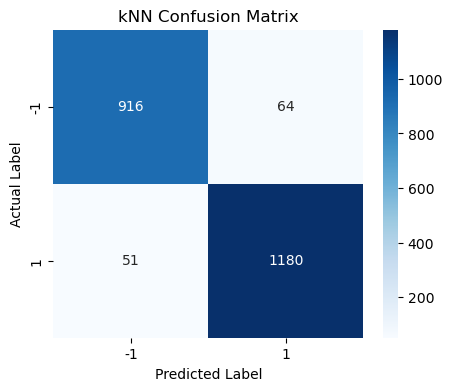

In [43]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['-1', '1'],
    yticklabels=['-1', '1']
)

plt.title('kNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Train Naive Bayes Classifier

In [44]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train, y_train)

print("Gaussian Naive Bayes Classifier trained successfully.")

Gaussian Naive Bayes Classifier trained successfully.


## Generate Naive Bayes Predictions

In [45]:
y_pred_nb = naive_bayes_model.predict(X_test)

y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]

print("Gaussian Naive Bayes predictions generated successfully.")
print("Number of Predictions:", len(y_pred_nb))

Gaussian Naive Bayes predictions generated successfully.
Number of Predictions: 2211


## Evaluate Gaussian Naive Bayes

In [46]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_prob_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_mcc = matthews_corrcoef(y_test, y_pred_nb)

print("Gaussian Naive Bayes Evaluation Metrics")
print("Accuracy :", round(nb_accuracy, 4))
print("AUC Score:", round(nb_auc, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))
print("MCC Score:", round(nb_mcc, 4))

Gaussian Naive Bayes Evaluation Metrics
Accuracy : 0.6006
AUC Score: 0.9702
Precision: 0.9971
Recall   : 0.2835
F1 Score : 0.4415
MCC Score: 0.3844


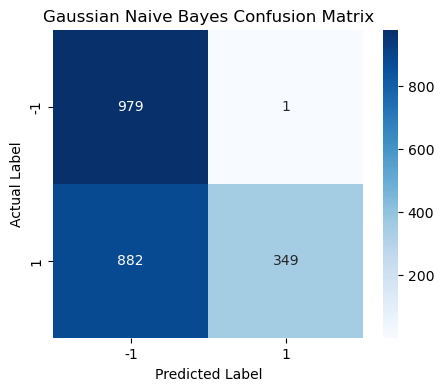

In [47]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['-1', '1'],
    yticklabels=['-1', '1']
)

plt.title('Gaussian Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Train Random Forest Classifier

In [48]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


## Generate Random Forest Predictions

In [49]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")
print("Number of Predictions:", len(y_pred_rf))

Random Forest predictions generated successfully.
Number of Predictions: 2211


## Evaluate Random Forest Classifier

In [50]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_mcc = matthews_corrcoef(y_test, y_pred_rf)

print("Random Forest Evaluation Metrics")
print("Accuracy :", round(rf_accuracy, 4))
print("AUC Score:", round(rf_auc, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("MCC Score:", round(rf_mcc, 4))

Random Forest Evaluation Metrics
Accuracy : 0.9742
AUC Score: 0.9977
Precision: 0.9696
Recall   : 0.9846
F1 Score : 0.977
MCC Score: 0.9478


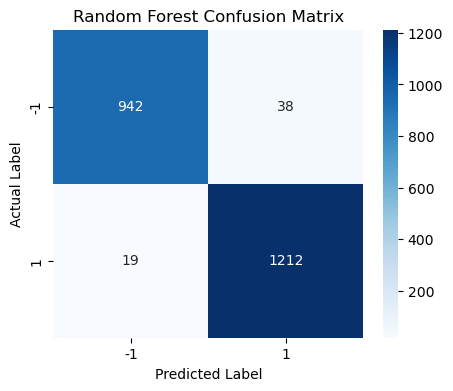

In [51]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['-1', '1'],
    yticklabels=['-1', '1']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Create Model Comparison Table

In [52]:
comparison_table = pd.DataFrame({
    'ML Model Name': [
        'Logistic Regression',
        'Decision Tree',
        'kNN',
        'Naive Bayes',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        dt_accuracy,
        knn_accuracy,
        nb_accuracy,
        rf_accuracy
    ],
    'AUC': [
        logistic_auc,
        dt_auc,
        knn_auc,
        nb_auc,
        rf_auc
    ],
    'Precision': [
        logistic_precision,
        dt_precision,
        knn_precision,
        nb_precision,
        rf_precision
    ],
    'Recall': [
        logistic_recall,
        dt_recall,
        knn_recall,
        nb_recall,
        rf_recall
    ],
    'F1': [
        logistic_f1,
        dt_f1,
        knn_f1,
        nb_f1,
        rf_f1
    ],
    'MCC': [
        logistic_mcc,
        dt_mcc,
        knn_mcc,
        nb_mcc,
        rf_mcc
    ]
})

comparison_table = comparison_table.round(4)

display(comparison_table)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9285,0.9808,0.9234,0.9504,0.9367,0.8551
1,Decision Tree,0.9711,0.9805,0.9702,0.9781,0.9741,0.9413
2,kNN,0.9480,0.9868,0.9486,0.9586,0.9535,0.8945
3,Naive Bayes,0.6006,0.9702,0.9971,0.2835,0.4415,0.3844
4,Random Forest,0.9742,0.9977,0.9696,0.9846,0.9770,0.9478


## Model Performance Comparison Graph

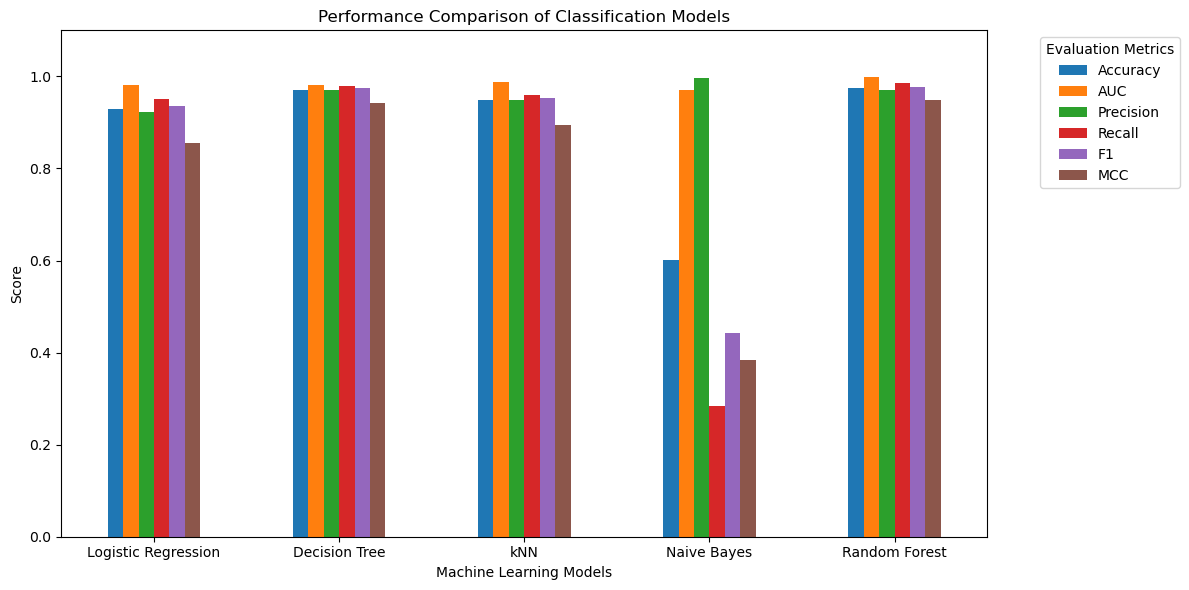

In [53]:
comparison_table.set_index('ML Model Name').plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Performance Comparison of Classification Models')
plt.xlabel('Machine Learning Models')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title='Evaluation Metrics', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Combined Confusion Matrices for All Models

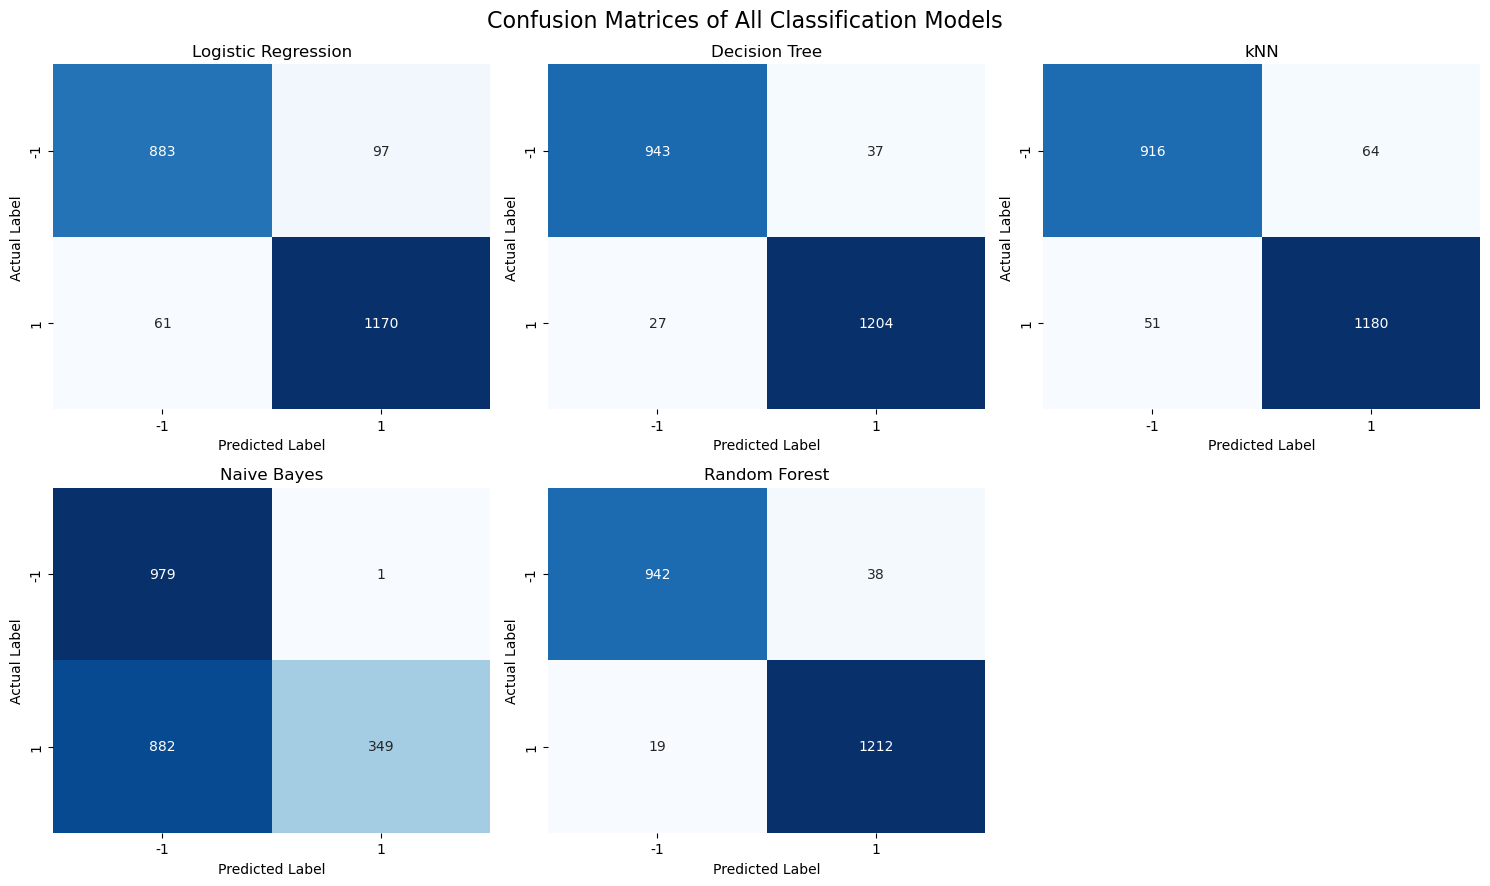

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

confusion_matrices = [
    (cm_logistic, 'Logistic Regression'),
    (cm_dt, 'Decision Tree'),
    (cm_knn, 'kNN'),
    (cm_nb, 'Naive Bayes'),
    (cm_rf, 'Random Forest')
]

for ax, (cm, model_name) in zip(axes.flat, confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['-1', '1'],
        yticklabels=['-1', '1'],
        ax=ax,
        cbar=False
    )

    ax.set_title(model_name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

axes[1, 2].axis('off')

plt.suptitle('Confusion Matrices of All Classification Models', fontsize=16)
plt.tight_layout()
plt.show()

## Model Performance Observations

In [55]:
observations = pd.DataFrame({
    'ML Model Name': [
        'Logistic Regression',
        'Decision Tree',
        'kNN',
        'Naive Bayes',
        'Random Forest',
        'Overall Winner'
    ],
    'Observation about Model Performance': [
        'Good overall performance with 92.85% accuracy and high AUC of 0.9808.',
        
        'Strong performance with 97.11% accuracy, high F1 score of 0.9741 and MCC of 0.9413.',
        
        'Good performance with 94.80% accuracy and a high AUC of 0.9868.',
        
        'Highest precision of 0.9971, but low recall of 0.2835 resulted in poor overall performance.',
        
        'Best overall performance with 97.42% accuracy, 0.9977 AUC, 0.9770 F1 score and 0.9478 MCC.',
        
        'Random Forest is the overall winner because it provides the best and most balanced performance across the evaluation metrics.'
    ]
})

display(observations)

,ML Model Name,Observation about Model Performance
0,Logistic Regression,Good overall performance with 92.85% accuracy ...
1,Decision Tree,"Strong performance with 97.11% accuracy, high ..."
2,kNN,Good performance with 94.80% accuracy and a hi...
3,Naive Bayes,"Highest precision of 0.9971, but low recall of..."
4,Random Forest,"Best overall performance with 97.42% accuracy,..."
5,Overall Winner,Random Forest is the overall winner because it...


In [56]:
pd.set_option('display.max_colwidth', None)

display(observations)

,ML Model Name,Observation about Model Performance
0,Logistic Regression,Good overall performance with 92.85% accuracy and high AUC of 0.9808.
1,Decision Tree,"Strong performance with 97.11% accuracy, high F1 score of 0.9741 and MCC of 0.9413."
2,kNN,Good performance with 94.80% accuracy and a high AUC of 0.9868.
3,Naive Bayes,"Highest precision of 0.9971, but low recall of 0.2835 resulted in poor overall performance."
4,Random Forest,"Best overall performance with 97.42% accuracy, 0.9977 AUC, 0.9770 F1 score and 0.9478 MCC."
5,Overall Winner,Random Forest is the overall winner because it provides the best and most balanced performance across the evaluation metrics.


## Save Trained Models and Scaler

In [58]:
import joblib

joblib.dump(logistic_model, 'logistic_regression.pkl')
joblib.dump(decision_tree_model, 'decision_tree.pkl')
joblib.dump(knn_model, 'knn.pkl')
joblib.dump(naive_bayes_model, 'naive_bayes.pkl')
joblib.dump(random_forest_model, 'random_forest.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("All trained models and scaler saved successfully.")

All trained models and scaler saved successfully.
